## Data Preprocessing

In [ ]:
import os
import numpy as np
import pandas as pd
# Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Plot
import matplotlib.pyplot as plt
# Utils
from Utilities import fs_xgb
# for feature importance
from xgboost import XGBRegressor, XGBClassifier

In [45]:
train = pd.read_csv("mlfactor_project_training.csv")
test  = pd.read_csv("mlfactor_project_testing.csv")

In [46]:
test.shape, train.shape

((70489, 96), (197990, 96))

In [47]:
train.T.iloc[:,0:10]

,0,1,2,3,4,5,6,7,8,9
stock_id,967,905,571,815,825,1111,1067,418,11,356
date,2002-01-31,2001-07-31,2012-07-31,2004-09-30,2000-10-31,2006-07-31,2001-07-31,2000-01-31,2013-03-31,2001-12-31
Advt_12M_Usd,0.34,0.65,0.1,0.92,0.56,0.33,0.28,0.88,0.76,0.86
Advt_3M_Usd,0.35,0.66,0.09,0.94,0.67,0.35,0.27,0.85,0.76,0.87
Advt_6M_Usd,0.36,0.66,0.09,0.93,0.62,0.35,0.29,0.89,0.76,0.86
...,...,...,...,...,...,...,...,...,...,...
Total_Debt_Capital,0.54,0.91,0.15,0.32,0.67,0.28,0.77,0.55,0.32,0.34
Total_Liabilities_Total_Assets,0.39,0.82,0.14,0.86,0.66,0.51,0.69,0.39,0.17,0.25
Vol1Y_Usd,0.36,0.65,0.84,0.04,0.89,0.61,0.44,0.74,0.28,0.31
Vol3Y_Usd,0.61,0.42,0.75,0.09,0.86,0.49,0.33,0.76,0.42,0.23


In [48]:
# Config
X = train.drop(columns=['R1M_Usd_C','stock_id','date'])

y = train['R1M_Usd_C']

## Using PCA to determine the optimal number of variable explaining 95% variance

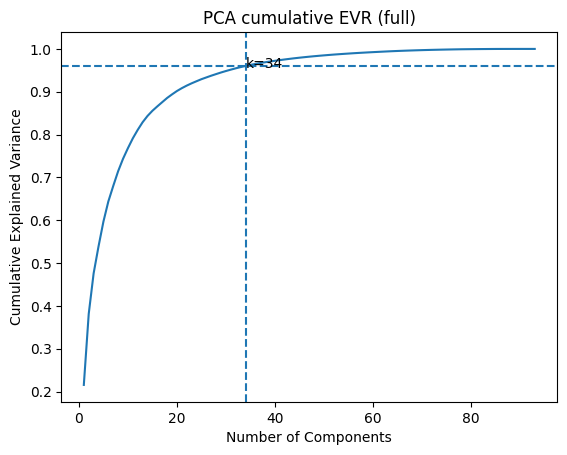

k for 95% variance: 34


In [ ]:
# Sacling + PCA to find k for 95% variance
Xs = StandardScaler().fit_transform(X) 
pca = PCA().fit(Xs)                      # full spectrum (up to min(n_samples, n_features))
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

def k_for(target):
    return int(np.argmax(cum >= target) + 1)

k95 = k_for(0.95)

plt.plot(np.arange(1, len(cum)+1), cum)
plt.axhline(0.95, linestyle='--')
plt.axvline(k95, linestyle='--')
plt.text(k95, 0.95, f'k={k95}', ha='left', va='bottom')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Explained Variance')
plt.title('PCA cumulative EVR (full) for 95%')
plt.show()

print("k for 95% variance:", k95)

## Feature Selection - xgb

#### Functions for xgboost feature selection, copied from utilities.py for ease of access

In [ ]:
# =============================================================================
# Feature selection utilities (minimal, XGBoost-focused)
#
# Typical flow:
#   X_topk, info = fs_xgb(X, y, n_features=35)
#   selected_cols = info["selected_features"]
#   # Use X_topk (and/or selected_cols) in your downstream modeling.
# =============================================================================

# _is_classification_target(y, max_unique_for_class=10) -> Heuristic to decide if y is a classification target vs. regression (many unique numeric values).
def _is_classification_target(y: pd.Series, max_unique_for_class: int = 10) -> bool:
    ys = pd.Series(y).dropna()
    if pd.api.types.is_bool_dtype(ys) or pd.api.types.is_integer_dtype(ys):
        return ys.nunique() <= max_unique_for_class
    if pd.api.types.is_categorical_dtype(ys) or pd.api.types.is_object_dtype(ys):
        return True
    return ys.nunique() <= max_unique_for_class

# _sanitize_X(X) -> Drops constant columns and median-imputes NaNs for the rest. Returns a clean numeric DataFrame suitable for modeling/feature selection.
def _sanitize_X(X: pd.DataFrame) -> pd.DataFrame:
    nunique = X.nunique(dropna=True)
    cols = nunique[nunique > 1].index.tolist()
    Xc = X[cols].copy()
    return Xc.apply(lambda s: s.fillna(s.median()))

## XGBoost feature selection
def fs_xgb(X: pd.DataFrame, y: pd.Series, n_features, random_state: int = 42):
    Xc = _sanitize_X(X)
    if _is_classification_target(y):
        model = XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            random_state=random_state, n_jobs=-1, objective="binary:logistic",
            eval_metric="auc"
        )
    else:
        model = XGBRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            random_state=random_state, n_jobs=-1, objective="reg:squarederror"
        )
    model.fit(Xc, y)
    try:
        booster = model.get_booster()
        score_dict = booster.get_score(importance_type="gain")
        mapping = {f"f{i}": col for i, col in enumerate(Xc.columns)}
        importances = pd.Series({mapping.get(k, k): v for k, v in score_dict.items()})
        importances = importances.reindex(Xc.columns).fillna(0.0)
    except Exception:
        importances = pd.Series(model.feature_importances_, index=Xc.columns)
    ranked = importances.sort_values(ascending=False).index.tolist()
    keep = ranked[: min(n_features, len(ranked))]
    return Xc[keep].copy(), {"method":"xgb","selected_features":keep,"importances":importances.to_dict()}

In [ ]:
# ---------- feature selector defined in Utilities file ----------
RANDOM_STATE = 42

def select_xgb(X, y, random_state = RANDOM_STATE):
    X_sel, info = fs_xgb(X, y, n_features=k95, random_state=random_state)
    return X_sel, info

In [ ]:
# declaration for xgb selector from Utilities.py
X_xgb,   xgb_info   = select_xgb(X, y)
xgb_features   = xgb_info["selected_features"]
selected_feats = xgb_features[:k95]

df_all   = train
df_feats = train[selected_feats + ['R1M_Usd_C','stock_id','date']]

# full feature list for the "all features" run
full_feats = [c for c in df_all.columns if c not in ['R1M_Usd_C','stock_id','date']]

## Pipelines and grids - Includes parameter tuning with both full and subset of features and model fitting

In [102]:
# ---- Runtime + imports
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from typing import List
from pprint import pprint
import numpy as np
import pandas as pd

from joblib import parallel_backend
from packaging import version as _pkg_version
import xgboost as _xgb
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score

In [ ]:
# =========================
# Grids: exactly 3 hyperparams per model
# =========================
GRID_LR = {
    "clf__C": [0.1, 0.5, 1, 2, 5],
    "clf__penalty": ["l2"],
    "clf__class_weight": [None, "balanced"],
}
GRID_XGB = {
    "clf__n_estimators":  [300, 600, 900],
    "clf__learning_rate": [0.03, 0.07, 0.15],
    "clf__min_child_weight": [1, 3, 5],   # stronger child weight
}
GRID_RF = {
    "clf__n_estimators": [200, 400],     # cut 800
    "clf__max_depth": [8, 12],           # drop None (deep trees are slow + overfit)
    "clf__max_features": ["sqrt", 0.3],  # drop 0.5
}

# =========================
# Scoring + CV
# =========================
SCORERS = {
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall":    make_scorer(recall_score, zero_division=0),
    "roc_auc":   "roc_auc",
}
# Group by stock_id to avoid leakage
cv = GroupKFold(n_splits=5)


In [ ]:
# =========================
# Memory-friendly preprocessors
# =========================
def make_preprocessor_lr(feats: List[str]):
    # float32 → median impute → scale (LogReg benefits from scaling)
    return ColumnTransformer(
        transformers=[("num", Pipeline([
            ("to_f32", FunctionTransformer(lambda X: X.astype("float32"), feature_names_out="one-to-one")),
            ("impute", SimpleImputer(strategy="median", copy=False)),
            ("scale",  StandardScaler(with_mean=True, with_std=True, copy=False)),
        ]), feats)],
        remainder="drop"
    )

## Rf speed update: avoid unnecessary copies when casting to float32
def _ensure_f32(X):
    # Cast only if needed to avoid extra copies
    return X.astype(np.float32, copy=False)

def make_preprocessor_rf(feats: List[str]):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("to_f32", FunctionTransformer(_ensure_f32, feature_names_out="one-to-one")),("impute", SimpleImputer(strategy="median", copy=False)),]), feats)],
        remainder="drop",
        sparse_threshold=0.0,          # force dense ndarray to downstream RF
        verbose_feature_names_out=False
    )

# =========================
# XGBoost GPU base kwargs
# =========================
def _xgb_gpu_base_kwargs():
    v = _pkg_version.parse(_xgb.__version__)
    base = dict(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        # regularization that helps smaller (cleaner) subsets:
        reg_lambda=2.0,          # L2
        reg_alpha=1e-4,          # tiny L1
        subsample=0.8,           # row sampling
        colsample_bytree=0.8,    # column sampling hurts "full" a bit more than a tight subset
        max_depth=4,             # shallow by default
    )
    if v >= _pkg_version.parse("2.0.0"):
        base.update(dict(device="cuda", tree_method="hist"))
    else:
        base.update(dict(tree_method="gpu_hist", predictor="gpu_predictor"))
    return base

def make_preprocessor_xgb(feats: List[str]):
    # XGB handles NaN natively → just cast to float32 (no imputer/scaler)
    return ColumnTransformer(
        transformers=[("num", FunctionTransformer(lambda X: X.astype("float32"), feature_names_out="one-to-one"), feats)],
        remainder="drop"
    )

In [106]:
# =========================
# Pipeline builder
# =========================
def grid_and_pipe(model: str, feats: List[str]):
    if model == "logreg":
        pipe = Pipeline([
            ("prep", make_preprocessor_lr(feats)),
            ("clf", LogisticRegression(
                solver="lbfgs", penalty="l2",
                max_iter=5000, tol=1e-4,
                n_jobs=1, random_state=42
            ))
        ])
        grid = GRID_LR

    elif model == "rf":
        pipe = Pipeline([
            ("prep", make_preprocessor_rf(feats)),   # impute only (no scaler)
            ("clf", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,              # let RF use all cores
                bootstrap=True,
                max_samples=0.6,        # subsample per tree -> big speedup, little perf loss
                min_samples_leaf=10,    # shallower leaves -> faster / stabler
                min_samples_split=20
            ))
        ])
        grid = GRID_RF

    elif model == "xgb":
        pipe = Pipeline([
            ("prep", make_preprocessor_xgb(feats)),
            ("clf", XGBClassifier(**_xgb_gpu_base_kwargs()))
        ])
        grid = GRID_XGB

    else:
        raise ValueError("Unknown model")
    return pipe, grid

In [ ]:
# =========================
# CV runner
# =========================

def run_grid(model: str, feats: List[str], dataset: str):
    """Run GridSearchCV on 'subset' (selected_feats) or 'full' (all feats)."""
    df = df_feats if dataset == "subset" else df_all

    # 1) Slice the DataFrame to the requested feature columns (keeps ordering)
    X_df = df[feats]

    # 2) Convert to NumPy (float32) to reduce memory; labels/groups as NumPy too
    X = X_df.to_numpy(dtype=np.float32, copy=False)
    y_vec = df["R1M_Usd_C"].to_numpy(dtype=np.int32, copy=False)
    g = df["stock_id"].to_numpy(copy=False)

    # 3) Since X is a NumPy array now, ColumnTransformer must select by indices
    feats_idx = list(range(X.shape[1]))

    # Build pipeline *with indices*, not names
    pipe, grid = grid_and_pipe(model, feats_idx)

    gcv = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=SCORERS,
        refit="roc_auc",
        cv=cv.split(X, y_vec, groups=g),
        n_jobs=1,                 # keep low for memory stability
        pre_dispatch="n_jobs",
        error_score="raise",
        verbose=0
    )
    with parallel_backend("threading"):
        gcv.fit(X, y_vec)

    res = pd.DataFrame(gcv.cv_results_)
    keep = [c for c in res.columns if c.startswith("mean_test_")] + ["params"]
    display(res[keep].sort_values("mean_test_roc_auc", ascending=False).head(10))
    return gcv.best_estimator_, gcv.best_params_

In [108]:
best = {}
final_models = {}

In [ ]:
### Execute grids + final fits

# ---------- LOGISTIC REGRESSION ----------
print("\n[LOGREG][SUBSET] running...")
logreg_subset_est, logreg_subset_params = run_grid("logreg", selected_feats, dataset="subset")
print("[LOGREG][SUBSET] best params:"); pprint(logreg_subset_params)
best["logreg_subset"] = (logreg_subset_est, logreg_subset_params)

print("\n[LOGREG][FULL] running...")
logreg_full_est, logreg_full_params = run_grid("logreg", full_feats, dataset="full")
print("[LOGREG][FULL] best params:"); pprint(logreg_full_params)
best["logreg_full"] = (logreg_full_est, logreg_full_params)

print("\n[LOGREG][SUBSET] fitting final on all rows...")
final_models["logreg_subset"] = logreg_subset_est.fit(
    df_feats[selected_feats].to_numpy(dtype=np.float32, copy=False),
    df_feats["R1M_Usd_C"].to_numpy(dtype=np.int32, copy=False)
)
print("[LOGREG][FULL] fitting final on all rows...")
final_models["logreg_full"] = logreg_full_est.fit(
    df_all[full_feats].to_numpy(dtype=np.float32, copy=False),
    df_all["R1M_Usd_C"].to_numpy(dtype=np.int32, copy=False)
)


[LOGREG][SUBSET] running...


,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,params
0,0.520132,0.519048,0.473859,0.527627,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
1,0.519410,0.516512,0.520102,0.527617,"{'clf__C': 0.1, 'clf__class_weight': 'balanced..."
7,0.519440,0.516548,0.520082,0.527612,"{'clf__C': 2, 'clf__class_weight': 'balanced',..."
8,0.520162,0.519079,0.473859,0.527610,"{'clf__C': 5, 'clf__class_weight': None, 'clf_..."
6,0.520162,0.519079,0.473869,0.527609,"{'clf__C': 2, 'clf__class_weight': None, 'clf_..."
4,0.520188,0.519106,0.473890,0.527608,"{'clf__C': 1, 'clf__class_weight': None, 'clf_..."
3,0.519561,0.516665,0.520113,0.527607,"{'clf__C': 0.5, 'clf__class_weight': 'balanced..."
5,0.519501,0.516607,0.520062,0.527607,"{'clf__C': 1, 'clf__class_weight': 'balanced',..."
2,0.520284,0.519211,0.473991,0.527606,"{'clf__C': 0.5, 'clf__class_weight': None, 'cl..."
9,0.519465,0.516574,0.520042,0.527606,"{'clf__C': 5, 'clf__class_weight': 'balanced',..."


[LOGREG][SUBSET] best params:
{'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l2'}

[LOGREG][FULL] running...


,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,params
9,0.521471,0.518239,0.531475,0.531627,"{'clf__C': 5, 'clf__class_weight': 'balanced',..."
1,0.521627,0.518377,0.532272,0.531627,"{'clf__C': 0.1, 'clf__class_weight': 'balanced..."
6,0.521173,0.519387,0.494216,0.531626,"{'clf__C': 2, 'clf__class_weight': None, 'clf_..."
2,0.521203,0.519406,0.494482,0.531616,"{'clf__C': 0.5, 'clf__class_weight': None, 'cl..."
3,0.521572,0.518324,0.531932,0.531615,"{'clf__C': 0.5, 'clf__class_weight': 'balanced..."
7,0.521395,0.518179,0.531253,0.531610,"{'clf__C': 2, 'clf__class_weight': 'balanced',..."
0,0.521370,0.519576,0.495025,0.531603,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl..."
8,0.521031,0.519234,0.494217,0.531586,"{'clf__C': 5, 'clf__class_weight': None, 'clf_..."
4,0.521309,0.519518,0.494758,0.531585,"{'clf__C': 1, 'clf__class_weight': None, 'clf_..."
5,0.521501,0.518285,0.531172,0.531566,"{'clf__C': 1, 'clf__class_weight': 'balanced',..."


[LOGREG][FULL] best params:
{'clf__C': 5, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}

[LOGREG][SUBSET] fitting final on all rows...
[LOGREG][FULL] fitting final on all rows...


In [110]:
import warnings
warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")

# ---------- XGBOOST (GPU) ----------
print("\n[XGB][SUBSET] running...")
xgb_subset_est, xgb_subset_params = run_grid("xgb", selected_feats, dataset="subset")
print("[XGB][SUBSET] best params:"); pprint(xgb_subset_params)
best["xgb_subset"] = (xgb_subset_est, xgb_subset_params)

print("\n[XGB][FULL] running...")
xgb_full_est, xgb_full_params = run_grid("xgb", full_feats, dataset="full")
print("[XGB][FULL] best params:"); pprint(xgb_full_params)
best["xgb_full"] = (xgb_full_est, xgb_full_params)

print("\n[XGB][SUBSET] fitting final on all rows...")
final_models["xgb_subset"] = xgb_subset_est.fit(
    df_feats[selected_feats].to_numpy(dtype=np.float32, copy=False),
    df_feats["R1M_Usd_C"].to_numpy(dtype=np.int32, copy=False)
)
print("[XGB][FULL] fitting final on all rows...")
final_models["xgb_full"] = xgb_full_est.fit(
    df_all[full_feats].to_numpy(dtype=np.float32, copy=False),
    df_all["R1M_Usd_C"].to_numpy(dtype=np.int32, copy=False)
)


[XGB][SUBSET] running...


,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,params
4,0.524643,0.521787,0.523785,0.534559,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
6,0.524001,0.521137,0.523551,0.534452,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
0,0.524375,0.521606,0.522873,0.534417,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
3,0.524274,0.521503,0.523068,0.534396,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
7,0.524031,0.521061,0.525174,0.534392,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
1,0.524430,0.521538,0.524601,0.534329,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
5,0.523158,0.520374,0.520661,0.533816,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
2,0.523329,0.520553,0.520871,0.533481,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
8,0.522956,0.520065,0.521949,0.533416,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
9,0.523168,0.520518,0.516934,0.533085,"{'clf__learning_rate': 0.07, 'clf__min_child_w..."


[XGB][SUBSET] best params:
{'clf__learning_rate': 0.03,
 'clf__min_child_weight': 3,
 'clf__n_estimators': 600}

[XGB][FULL] running...


,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,params
7,0.526627,0.523900,0.525113,0.538687,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
4,0.526456,0.523721,0.524597,0.538679,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
1,0.526294,0.523660,0.523426,0.538546,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
6,0.526077,0.523489,0.520488,0.538478,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
8,0.525971,0.523295,0.523826,0.538474,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
5,0.527057,0.524305,0.526653,0.538409,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
3,0.526133,0.523565,0.520929,0.538344,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
2,0.526537,0.523857,0.524126,0.538258,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
0,0.526138,0.523539,0.521403,0.538146,"{'clf__learning_rate': 0.03, 'clf__min_child_w..."
12,0.526087,0.523409,0.521574,0.537891,"{'clf__learning_rate': 0.07, 'clf__min_child_w..."


[XGB][FULL] best params:
{'clf__learning_rate': 0.03,
 'clf__min_child_weight': 5,
 'clf__n_estimators': 600}

[XGB][SUBSET] fitting final on all rows...
[XGB][FULL] fitting final on all rows...


In [111]:
# ---------- RANDOM FOREST ----------
print("\n[RF][SUBSET] running...")
rf_subset_est, rf_subset_params = run_grid("rf", selected_feats, dataset="subset")
print("[RF][SUBSET] best params:"); pprint(rf_subset_params)
best["rf_subset"] = (rf_subset_est, rf_subset_params)

print("\n[RF][FULL] running...")
rf_full_est, rf_full_params = run_grid("rf", full_feats, dataset="full")
print("[RF][FULL] best params:"); pprint(rf_full_params)
best["rf_full"] = (rf_full_est, rf_full_params)

print("\n[RF][SUBSET] fitting final on all rows...")
final_models["rf_subset"] = rf_subset_est.fit(
    df_feats[selected_feats].to_numpy(dtype=np.float32, copy=False),
    df_feats["R1M_Usd_C"].to_numpy(dtype=np.int32, copy=False)
)
print("[RF][FULL] fitting final on all rows...")
final_models["rf_full"] = rf_full_est.fit(
    df_all[full_feats].to_numpy(dtype=np.float32, copy=False),
    df_all["R1M_Usd_C"].to_numpy(dtype=np.int32, copy=False)
)


[RF][SUBSET] running...


c:\Users\bhanu\anaconda3\envs\xgb-gpu\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,params
7,0.524643,0.520837,0.546907,0.536518,"{'clf__max_depth': 12, 'clf__max_features': 0...."
6,0.524870,0.521045,0.546934,0.535783,"{'clf__max_depth': 12, 'clf__max_features': 0...."
5,0.523971,0.520408,0.542902,0.535642,"{'clf__max_depth': 12, 'clf__max_features': 's..."
3,0.523153,0.519419,0.548752,0.534976,"{'clf__max_depth': 8, 'clf__max_features': 0.3..."
4,0.523430,0.519807,0.544148,0.534709,"{'clf__max_depth': 12, 'clf__max_features': 's..."
2,0.523501,0.519593,0.551682,0.534373,"{'clf__max_depth': 8, 'clf__max_features': 0.3..."
1,0.523208,0.519502,0.548346,0.534299,"{'clf__max_depth': 8, 'clf__max_features': 'sq..."
0,0.523198,0.519303,0.552371,0.533907,"{'clf__max_depth': 8, 'clf__max_features': 'sq..."


[RF][SUBSET] best params:
{'clf__max_depth': 12, 'clf__max_features': 0.3, 'clf__n_estimators': 400}

[RF][FULL] running...


,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,params
7,0.526218,0.522734,0.539772,0.539013,"{'clf__max_depth': 12, 'clf__max_features': 0...."
6,0.524345,0.520859,0.539973,0.537873,"{'clf__max_depth': 12, 'clf__max_features': 0...."
5,0.525430,0.522061,0.539247,0.537402,"{'clf__max_depth': 12, 'clf__max_features': 's..."
4,0.525067,0.521526,0.541640,0.537003,"{'clf__max_depth': 12, 'clf__max_features': 's..."
3,0.524941,0.521096,0.550306,0.536663,"{'clf__max_depth': 8, 'clf__max_features': 0.3..."
2,0.524835,0.520893,0.551304,0.536220,"{'clf__max_depth': 8, 'clf__max_features': 0.3..."
1,0.523577,0.519735,0.549559,0.534808,"{'clf__max_depth': 8, 'clf__max_features': 'sq..."
0,0.523930,0.519999,0.551367,0.534295,"{'clf__max_depth': 8, 'clf__max_features': 'sq..."


[RF][FULL] best params:
{'clf__max_depth': 12, 'clf__max_features': 0.3, 'clf__n_estimators': 400}

[RF][SUBSET] fitting final on all rows...
[RF][FULL] fitting final on all rows...


In [ ]:
# Summary
print("\n=== Best Params Summary ===")
summary = {
    "logreg_subset": logreg_subset_params,
    "logreg_full":   logreg_full_params,
    "rf_subset":     rf_subset_params,
    "rf_full":       rf_full_params,
    "xgb_subset":    xgb_subset_params,
    "xgb_full":      xgb_full_params,
}
pprint(summary)


=== Best Params Summary ===
{'logreg_full': {'clf__C': 5,
                 'clf__class_weight': 'balanced',
                 'clf__penalty': 'l2'},
 'logreg_subset': {'clf__C': 0.1,
                   'clf__class_weight': None,
                   'clf__penalty': 'l2'},
 'rf_full': {'clf__max_depth': 12,
             'clf__max_features': 0.3,
             'clf__n_estimators': 400},
 'rf_subset': {'clf__max_depth': 12,
               'clf__max_features': 0.3,
               'clf__n_estimators': 400},
 'xgb_full': {'clf__learning_rate': 0.03,
              'clf__min_child_weight': 5,
              'clf__n_estimators': 600},
 'xgb_subset': {'clf__learning_rate': 0.03,
                'clf__min_child_weight': 3,
                'clf__n_estimators': 600}}


### What we did to tune (subset vs. full).
Each model LogisticRegression, RandomForest, and XGBoost was tuned twice: once on the 34-feature subset (96% variance) and once on the full feature set. We used the same protocol throughout, 5-fold GroupKFold (grouped by stock_id), GridSearchCV with exactly three hyperparameters per model, and multi-metric scoring (accuracy, precision, recall, ROC-AUC) with refit on ROC-AUC. Preprocessing was model-appropriate: scaling for LR, impute-only for RF, and pass-through float32 for XGB (GPU), keeping the evaluation fair and comparable across the two feature regimes.

### Do the optimal parameters change?
Yes, in intuitive ways based on your best-param summary. LogisticRegression moved from heavier regularization on the subset (C=0.1, no class-weight) to looser regularization with balancing on the full set (C=5, class_weight='balanced'), consistent with extra features adding variance and mild imbalance. RandomForest was essentially invariant (400 trees, depth 12, max_features=0.3)—signal seemed well captured either way. XGBoost chose the same rounds and LR in both cases (600, 0.03) but preferred heavier min_child_weight on full (5 vs 3), i.e., more conservative splits to handle the larger feature space. In short: full features nudged LR toward less regularization + balancing, made XGB slightly stricter on splits, and left RF largely unchanged.

## Backtest on the test data - includes performance comparison of models trained on full vs subset of features

In [ ]:
# =========================
# Backtest setup
# =========================
DATE_COL   = "date"
ID_COL     = "stock_id"
LABEL_COL  = "R1M_Usd_C"
RETURN_COL = "R1M_Usd"

# Sanity checks
assert DATE_COL in test.columns and ID_COL in test.columns, "test must have date/stock_id"
assert RETURN_COL in test.columns, f"test must contain forward returns in column '{RETURN_COL}'"

# Feature matrices for test
Xtest_subset_df = test[selected_feats]
Xtest_full_df   = test[full_feats]

# Convert to NumPy (aligns with training pipelines)
Xtest_subset = Xtest_subset_df.to_numpy(dtype=np.float32, copy=False)
Xtest_full   = Xtest_full_df.to_numpy(dtype=np.float32, copy=False)

# Helper: probability/score extractor for positive class
def positive_score(estimator, X):
    # Works for LR/RF/XGB
    if hasattr(estimator, "predict_proba"):
        p = estimator.predict_proba(X)
        # scikit sometimes returns shape (n,2). positive class is column 1
        return p[:, 1]
    elif hasattr(estimator, "decision_function"):
        z = estimator.decision_function(X)
        zmin, zmax = z.min(), z.max()
        return (z - zmin) / (zmax - zmin + 1e-12)
    else:
        # last resort: predict; map {0,1} to [0,1]
        return estimator.predict(X).astype(float)

# Build per-model score DataFrames on test
score_frames = []

def add_scores(model_key, estimator, X, feats_kind):
    s = positive_score(estimator, X)
    df = pd.DataFrame({
        DATE_COL: test[DATE_COL].values,
        ID_COL:   test[ID_COL].values,
        "score":  s,
        "ret_fwd": test[RETURN_COL].values,
        "model": model_key,
        "feats": feats_kind
    })
    score_frames.append(df)

# Add all six models
add_scores("logreg", final_models["logreg_subset"], Xtest_subset, "subset")
add_scores("logreg", final_models["logreg_full"],   Xtest_full,   "full")

add_scores("rf",     final_models["rf_subset"],     Xtest_subset, "subset")
add_scores("rf",     final_models["rf_full"],       Xtest_full,   "full")

add_scores("xgb",    final_models["xgb_subset"],    Xtest_subset, "subset")
add_scores("xgb",    final_models["xgb_full"],      Xtest_full,   "full")

scores_all = pd.concat(score_frames, ignore_index=True)

In [115]:
# =========================
# Portfolio construction
# =========================
# Strategy: Each month, go long the top decile by score (equal weight).
# You can switch to long-short by also shorting the bottom decile (see comment below).

TOP_PCT = 0.10

def monthly_portfolio_returns(df_scores, top_pct=TOP_PCT, long_short=False):
    # rank within (date, model, feats)
    df = df_scores.copy()
    df["rank"] = df.groupby([DATE_COL, "model", "feats"])["score"].rank(method="first", ascending=False)
    # number of names per bucket per month
    counts = df.groupby([DATE_COL, "model", "feats"])["score"].transform("count")
    k = (counts * top_pct).clip(lower=1).astype(int)
    df["is_long"] = df["rank"] <= k

    if long_short:
        # mirror symmetric short on bottom decile
        df["rank_asc"] = df.groupby([DATE_COL, "model", "feats"])["score"].rank(method="first", ascending=True)
        df["is_short"] = df["rank_asc"] <= k
        # equal weight long and equal weight short with same cardinality
        df["w"] = 0.0
        df.loc[df["is_long"],  "w"] =  1.0
        df.loc[df["is_short"], "w"] = -1.0
        # normalize weights to sum to 1 in absolute value (long+short have same count)
        def normalize(group):
            npos = (group["w"] > 0).sum()
            nneg = (group["w"] < 0).sum()
            if npos > 0: group.loc[group["w"] > 0, "w"] =  1.0 / max(npos, 1)
            if nneg > 0: group.loc[group["w"] < 0, "w"] = -1.0 / max(nneg, 1)
            return group
        df = df.groupby([DATE_COL, "model", "feats"], group_keys=False).apply(normalize)
    else:
        # long-only top decile: equal weights sum to 1 each month
        def long_only_weights(group):
            k_local = (len(group) * top_pct)
            k_local = max(int(k_local), 1)
            winners = group.nlargest(k_local, "score")
            w = pd.Series(0.0, index=group.index)
            w.loc[winners.index] = 1.0 / k_local
            group["w"] = w.values
            return group
        df = df.groupby([DATE_COL, "model", "feats"], group_keys=False).apply(long_only_weights)

    # portfolio return = sum(w_i * next-month-return_i)
    port = df.groupby([DATE_COL, "model", "feats"], as_index=False).apply(
        lambda g: pd.Series({"port_ret": (g["w"] * g["ret_fwd"]).sum()})
    )

    # also compute equal-weight benchmark across the universe (per month)
    ew = df_scores.groupby(DATE_COL)["ret_fwd"].mean().rename("ew_bench").reset_index()
    port = port.merge(ew, on=DATE_COL, how="left")
    return port.sort_values(DATE_COL)

# choose long_only or long_short:
bt = monthly_portfolio_returns(scores_all, top_pct=TOP_PCT, long_short=False)

C:\Users\bhanu\AppData\Local\Temp\ipykernel_5460\4264094903.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby([DATE_COL, "model", "feats"], group_keys=False).apply(long_only_weights)
C:\Users\bhanu\AppData\Local\Temp\ipykernel_5460\4264094903.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  port = df.groupby([DATE_COL, "model", "feats"], as_index=False).apply(


In [127]:
# =========================
# Performance metrics
# =========================

def performance_table(bt_df):

    #drawdown helper
    def max_drawdown(cumret):
        peak = cumret.cummax()
        dd = (cumret / peak) - 1.0
        return dd.min()

    out = []
    for (model, feats), g in bt_df.groupby(["model", "feats"]):
        r = g["port_ret"].values
        mu = np.nanmean(r)
        sig = np.nanstd(r, ddof=1)

        #Annualized return
        ann_ret = (1 + mu) ** 12 - 1

        ## Annualized volatility
        ann_vol = sig * np.sqrt(12)

        #Sharpe
        sharpe = (mu / sig) * np.sqrt(12) if sig > 0 else np.nan

        # drawdown on cumulative wealth
        cum = (1 + g["port_ret"]).cumprod()
        mdd = max_drawdown(cum)
        worst = g["port_ret"].min()

        # benchmark stats alongside
        rb = g["ew_bench"].values
        mub = np.nanmean(rb); sigb = np.nanstd(rb, ddof=1)
        ann_retb = (1 + mub) ** 12 - 1
        ann_volb = sigb * np.sqrt(12)
        sharpeb = (mub / sigb) * np.sqrt(12) if sigb > 0 else np.nan
        worstb = g["ew_bench"].min()
        cumb = (1 + g["ew_bench"]).cumprod()
        mddb = max_drawdown(cumb)

        out.append({
            "Model": model, "Features": feats,
            "Ann.Return": ann_ret, "Ann.Vol": ann_vol, "Sharpe": sharpe,
            "MaxDD": mdd, "WorstMonth": worst,
            "Benchmark Ann.Return": ann_retb, "Benchmark Ann.Vol": ann_volb,
            "Benchmark Sharpe": sharpeb, "Benchmark MaxDD": mddb, "Benchmark WorstMonth": worstb
        })
    return pd.DataFrame(out).sort_values(["Model","Features"])

perf = performance_table(bt)
display(perf)

,Model,Features,Ann.Return,Ann.Vol,Sharpe,MaxDD,WorstMonth,Benchmark Ann.Return,Benchmark Ann.Vol,Benchmark Sharpe,Benchmark MaxDD,Benchmark WorstMonth
0,logreg,full,0.117959,0.205726,0.544531,-0.266399,-0.164764,0.089952,0.136387,0.633809,-0.171111,-0.10693
1,logreg,subset,0.120328,0.192518,0.592989,-0.253796,-0.160255,0.089952,0.136387,0.633809,-0.171111,-0.10693
2,rf,full,0.253536,0.244641,0.932425,-0.285669,-0.189736,0.089952,0.136387,0.633809,-0.171111,-0.10693
3,rf,subset,0.253418,0.248932,0.915966,-0.276559,-0.182973,0.089952,0.136387,0.633809,-0.171111,-0.10693
4,xgb,full,0.271270,0.246279,0.984383,-0.276315,-0.176173,0.089952,0.136387,0.633809,-0.171111,-0.10693
5,xgb,subset,0.245441,0.241487,0.917275,-0.265468,-0.168982,0.089952,0.136387,0.633809,-0.171111,-0.10693


# Conclusion: which model to trade

Across the six variants, XGB (full features) delivered the best overall portfolio performance: highest annualized return (~27%) and top Sharpe (~0.98), with drawdown comparable to RF and materially better results than the equal-weight benchmark. XGB (Subset) has a good performace too with annualized return of (~25%) as well hence XGB performance was better in over all. 

RF (full) was a close (Sharpe ~0.93, strong return ~25%), while the subset versions of both models trailed their full-feature counterparts by a small but consistent margin. 

Logistic Regression is clearly the conservative baseline here lower return and Sharpe but can still serve as a low-variance, low-turnover reference.

#### Execution time trade-offs: Full-feature grids are materially slower and more memory-intensive. GPU acceleration mitigated XGB training time, but preprocessing and cross-validation still dominated wall-clock. Where faster iteration or tighter resource budgets are required, XGB (subset) offers a pragmatic balance between accuracy and runtime.

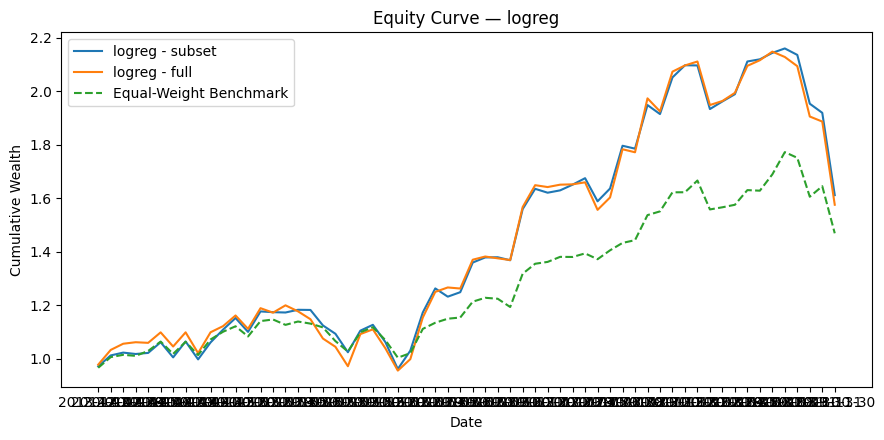

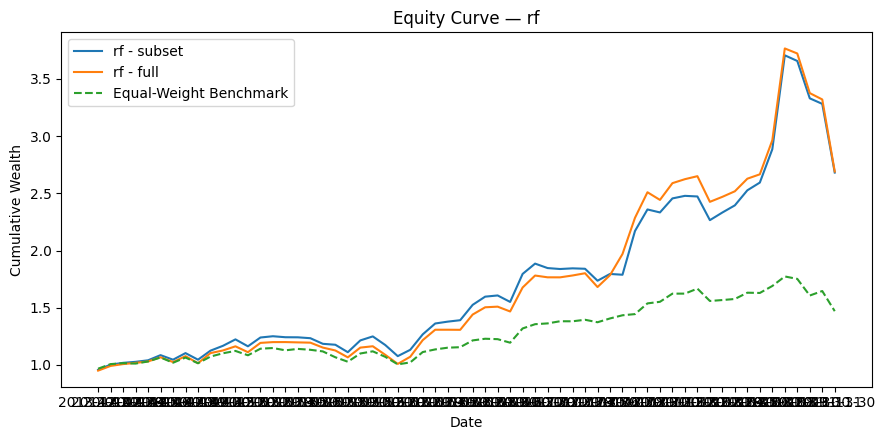

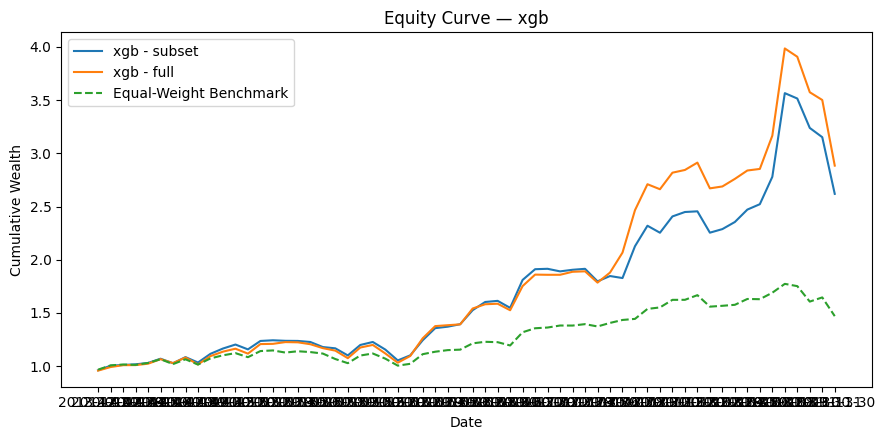

In [ ]:
# =========================
# Equity curves: subset/full + benchmark
# =========================
import matplotlib.pyplot as plt

models_to_plot = ["logreg", "rf", "xgb"]

for mdl in models_to_plot:
    dfm = bt[bt["model"] == mdl].sort_values(DATE_COL)

    # curves for subset/full
    sub = dfm[dfm["feats"] == "subset"].sort_values(DATE_COL)
    ful = dfm[dfm["feats"] == "full"].sort_values(DATE_COL)

    # guard in case one split is missing
    if sub.empty or ful.empty:
        print(f"[warn] Missing subset/full for model={mdl}; skipping.")
        continue

    eq_sub = (1.0 + sub["port_ret"]).cumprod()
    eq_ful = (1.0 + ful["port_ret"]).cumprod()

    # benchmark is same across models per date; take distinct by date
    bench_dates = dfm[[DATE_COL, "ew_bench"]].drop_duplicates(DATE_COL).sort_values(DATE_COL)
    eq_bench = (1.0 + bench_dates["ew_bench"]).cumprod()

    # align x-axis
    dates_sub = sub[DATE_COL].values
    dates_ful = ful[DATE_COL].values
    dates_bmk = bench_dates[DATE_COL].values

    plt.figure(figsize=(9, 4.5))
    plt.plot(dates_sub, eq_sub, label=f"{mdl} - subset")
    plt.plot(dates_ful, eq_ful, label=f"{mdl} - full")
    plt.plot(dates_bmk, eq_bench, label="Equal-Weight Benchmark", linestyle="--")
    plt.title(f"Equity Curve — {mdl}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Wealth")
    plt.legend()
    plt.tight_layout()
    plt.show()


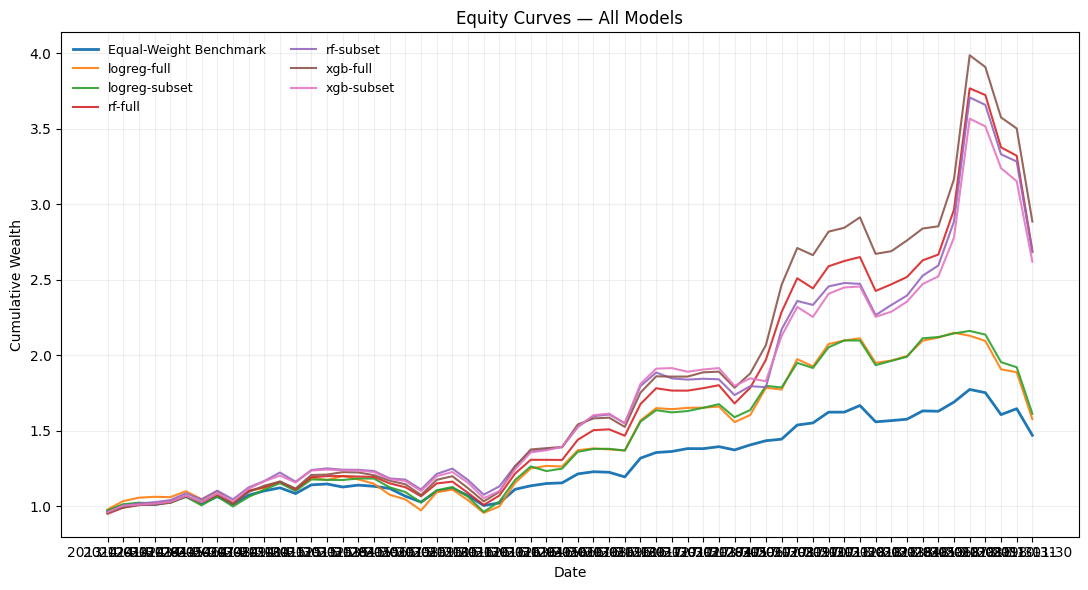

In [126]:
# Build benchmark once (one value per date)
bench_series = (
    bt[[DATE_COL, "ew_bench"]]
      .drop_duplicates(subset=[DATE_COL])
      .set_index(DATE_COL)["ew_bench"]
)
bench_curve = (1 + bench_series).cumprod()

fig, ax = plt.subplots(figsize=(11, 6))

# Benchmark first
ax.plot(bench_curve.index, bench_curve.values,
        label="Equal-Weight Benchmark", linewidth=2)

# All model/feature combos
for (model, feats), g in bt.groupby(["model", "feats"]):
    g = g.sort_values(DATE_COL)
    eq_curve = (1 + g["port_ret"]).cumprod()
    ax.plot(g[DATE_COL], eq_curve.values, label=f"{model}-{feats}", alpha=0.9)

ax.set_title("Equity Curves — All Models")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Wealth")
ax.legend(ncol=2, fontsize=9, frameon=False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
